# Model Experimentation

This notebook contains the code used to examine and test different models for the purpose of predicting whether a given flight would or would not be delayed.

## Basic Setup

In [ ]:
# General imports
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from category_encoders import TargetEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from pathlib import Path
import sys
import pandas as pd

sys.path.append(str(Path().resolve().parents[0] / "src"))

from flight_delay_prediction.utils import compare_models, evaluate_model
from flight_delay_prediction.features import train_test_split_model_data
from flight_delay_prediction.config import SEED


In [2]:
# Load the cleaned pre-encoding data
model_df = pd.read_parquet(Path().cwd().parent/ "data/processed/cleaned_pre_encoding_data.parquet")
model_df

,Origin,CRSElapsedTime,AirTime,Distance,Year,IsWeekend,Season,CRSArr_TimeOfDay,CRSDep_TimeOfDay,IsDelayed,...,origin_rain_sum,origin_snowfall_sum,origin_precipitation_hours,origin_weather_code,origin_temperature_2m_range,airline_name,SinMonth,CosMonth,SinDay,CosDay
0,FLL,158.0,130.0,992.0,2020,0,Winter,Night,Night,0,...,0.0,0.0,0.0,1,9.3,JetBlue Airways,0.5,0.866025,0.394356,0.918958
1,FLL,158.0,128.0,992.0,2020,0,Winter,Night,Night,0,...,0.0,0.0,0.0,3,8.3,JetBlue Airways,0.5,0.866025,0.571268,0.820763
2,FLL,158.0,124.0,992.0,2020,0,Winter,Night,Night,0,...,0.0,0.0,0.0,3,4.1,JetBlue Airways,0.5,0.866025,0.724793,0.688967
3,FLL,158.0,119.0,992.0,2020,1,Winter,Night,Night,0,...,0.0,0.0,0.0,3,5.7,JetBlue Airways,0.5,0.866025,0.848644,0.528964
4,FLL,158.0,131.0,992.0,2020,1,Winter,Night,Night,0,...,0.5,0.0,3.0,51,10.0,JetBlue Airways,0.5,0.866025,0.937752,0.347305
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
475369,MIA,176.0,140.0,1013.0,2025,1,Summer,Afternoon,Morning,0,...,0.0,0.0,0.0,3,5.0,Spirit Air Lines,-0.5,-0.866025,0.848644,0.528964
475370,MIA,170.0,143.0,1013.0,2025,0,Summer,Evening,Afternoon,0,...,0.4,0.0,3.0,51,7.6,Spirit Air Lines,-0.5,-0.866025,0.000000,1.000000
475371,MIA,170.0,187.0,1013.0,2025,0,Summer,Evening,Afternoon,1,...,0.0,0.0,0.0,1,5.3,Spirit Air Lines,-0.5,-0.866025,0.724793,0.688967
475372,MIA,176.0,138.0,1013.0,2025,1,Summer,Afternoon,Morning,0,...,0.0,0.0,0.0,2,7.6,Spirit Air Lines,-0.5,-0.866025,0.848644,0.528964


In [3]:
# Create list of columns that require One Hot Encoding
oh_encoding_cols = ["Year", "Season", "CRSArr_TimeOfDay", "CRSDep_TimeOfDay"]

# Create list of columns that require Target Encoding
target_encoding_cols = ["Origin", "dest_weather_code", "origin_weather_code", "airline_name"]

# Define target variable and numeric columns that do not need encoding
target = "IsDelayed"

numeric_cols = ["CRSElapsedTime", "AirTime", "Distance", "dest_temperature_2m_mean", "dest_wind_speed_10m_max",
                "dest_wind_gusts_10m_max", "dest_precipitation_sum", "dest_rain_sum", "dest_snowfall_sum",
                "dest_precipitation_hours", "dest_temperature_2m_range", "origin_temperature_2m_mean",
                "origin_wind_speed_10m_max", "origin_wind_gusts_10m_max", "origin_precipitation_sum",
                "origin_rain_sum", "origin_snowfall_sum", "origin_precipitation_hours", "origin_temperature_2m_range",
                "SinMonth", "CosMonth", "SinDay", "CosDay"]

In [4]:
# train test split
X_train, X_test, y_train, y_test = train_test_split_model_data(model_df)

print(f"Training features df shape: {X_train.shape[0]} rows and {X_train.shape[1]} columns.")
print(f"Testing features df shape: {X_test.shape[0]} rows and {X_test.shape[1]} columns.")

Training features df shape: 332761 rows and 32 columns.
Testing features df shape: 142613 rows and 32 columns.


## Standard Models Base Experiment

Below we define the preprocessors and pipelines for the models we want to test. Then we evaluate the models by looking at average precision. Finally, we perform 5-fold cross validation to choose optimal hyperparameters for the best performing model.

#### Baseline Logistic Regression

We begin with a baseline weighted Logistic Regression model. 

In [5]:
from sklearn.linear_model import LogisticRegression

# Set up preprocessing pipeline
lrg_preprocessor = ColumnTransformer(
    transformers = [
        ("scale_numeric", StandardScaler(), numeric_cols),
        ("ohe", OneHotEncoder(drop = "first"), oh_encoding_cols),
        ("te", TargetEncoder(smoothing = 10), target_encoding_cols)
    ]
)

# Logistic Regression pipeline
lrg_pipeline = Pipeline([
    ("preprocessor", lrg_preprocessor),
    ("weighted_lrg", LogisticRegression(
        max_iter = 2000,
        class_weight = "balanced"
    ))
])

,steps,"[('preprocessor', ...), ('weighted_lrg', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('scale_numeric', ...), ('ohe', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


#### Decision Tree Classifier

Then, we explore non-parametric methods by implementing a Decision Tree classifier.

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt_preprocessor = ColumnTransformer(
    transformers = [
        ("ohe", OneHotEncoder(drop = "first"), oh_encoding_cols),
        ("te", TargetEncoder(smoothing = 10), target_encoding_cols)
    ]
)

dt_pipeline = Pipeline([
    ("preprocessor", dt_preprocessor),
    ("dt", DecisionTreeClassifier(
        max_depth = 5,
        class_weight = "balanced",
        random_state = SEED
    ))
])

#### Random Forest Classifier

Next, we explore ensemble methods by first implementing a Random Forest classifier.

In [27]:
from sklearn.ensemble import RandomForestClassifier
rf_preprocessor = ColumnTransformer(
    transformers = [
        ("ohe", OneHotEncoder(drop = "first"), oh_encoding_cols),
        ("te", TargetEncoder(smoothing = 10), target_encoding_cols)
    ], remainder = "passthrough"
)

rf_pipeline = Pipeline([
    ("preprocessor", rf_preprocessor),
    ("rf", RandomForestClassifier(
        class_weight = "balanced",
        random_state = SEED
    ))
])

In [ ]:
rf_model = rf_pipeline.named_steps["rf"]
rf_preproc = rf_pipeline.named_steps["preprocessor"]
feature_names = rf_preproc.get_feature_names_out()
importances = rf_model.feature_importances_

imp_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending = False)

imp_df.head(10)

#### XGBoost Classifier

Next we implement an XGBoost classifier.

In [ ]:
from xgboost import XGBClassifier

# Set up preprocessing
preprocessor = ColumnTransformer(
    transformers = [
        ("ohe", OneHotEncoder(drop = "first"), oh_encoding_cols),
        ("te", TargetEncoder(smoothing = 10), target_encoding_cols)
    ], remainder = "passthrough"
)

# Build pipeline
xg_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("xgb", XGBClassifier(
        eval_metric = "logloss",
        scale_pos_weight = (y_train == 0).sum()/(y_train == 1).sum(),
        random_state = SEED
    ))
])

#### Logistic Regression with PCA weather features

Finally, we implement a weighted logistic regression with PCA'd weather features.

In [29]:
from flight_delay_prediction.data import load_PCA_train_and_test
train_PCA_df, test_PCA_df = load_PCA_train_and_test()

X_train_PCA = train_PCA_df.drop(columns = "IsDelayed")
y_train_PCA = train_PCA_df["IsDelayed"]

X_test_PCA = test_PCA_df.drop(columns = "IsDelayed")
y_test_PCA = test_PCA_df["IsDelayed"]

non_pca_numeric_cols = ["CRSElapsedTime", "AirTime", "Distance",
                        "SinMonth", "CosMonth", "SinDay", "CosDay"]

In [30]:
lrg_PCA_preprocessor = ColumnTransformer(
    transformers = [
        ("scale_numeric", StandardScaler(), non_pca_numeric_cols),
        ("ohe", OneHotEncoder(drop = "first"), oh_encoding_cols),
        ("te", TargetEncoder(smoothing = 10), target_encoding_cols)
    ], remainder = "passthrough"
)

lrg_PCA_pipeline = Pipeline([
    ("preprocessor", lrg_PCA_preprocessor),
    ("weighted_lrg", LogisticRegression(
        max_iter = 2000,
        class_weight = "balanced"
    ))
])

lrg_PCA_pipeline.fit(X_train_PCA, y_train_PCA)

metrics = evaluate_model(lrg_PCA_pipeline, X_train_PCA, y_train_PCA, X_test_PCA, y_test_PCA)
metrics["model"] = "Logistic Regression with PCA Weather Features"

### Compare models

Now that we have all of the pipelines for our models, we can easily compare their performance with each other.

In [31]:
# Compile all models using standard training and testing data
models = {
    "Weighted Baseline Logistic Regression": lrg_pipeline,
    "Decision Tree": dt_pipeline,
    "Random Forest": rf_pipeline,
    "XGBoost": xg_pipeline
}

# Generate list of comparison metrics for all models
comparison_metrics = compare_models(models, X_train, y_train, X_test, y_test)

Training Weighted Baseline Logistic Regression...
Training Decision Tree...
Training Random Forest...
Training XGBoost...


In [67]:
# Append PCA LogReg metrics to comparison metrics
# comparison_metrics.append(metrics) # commented out so I don't keep appending the PCA LogReg metrics every time I run the cell

# Display as DataFrame
comparison_df = pd.DataFrame(comparison_metrics).set_index("model").sort_values("test_avg_precision", ascending = False).iloc[:,::-1]

comparison_df.T # Make metrics the index and models the columns for easier comparison across models

model,XGBoost,Random Forest,Logistic Regression with PCA Weather Features,Weighted Baseline Logistic Regression,Decision Tree
test_avg_precision,0.478270,0.400664,0.392000,0.391155,0.310101
test_roc_auc,0.755914,0.718663,0.713136,0.713308,0.668782
test_f1,0.467524,0.268631,0.422130,0.423249,0.389111
test_precision,0.364679,0.532286,0.309476,0.310544,0.269774
test_recall,0.651163,0.179648,0.663741,0.664363,0.697784
test_accuracy,0.715566,0.812415,0.651518,0.652788,0.579849
train_avg_precision,0.535823,0.999958,0.386238,0.385851,0.309439
train_roc_auc,0.797390,0.999991,0.711752,0.712136,0.668507
train_f1,0.501888,0.999444,0.423544,0.424479,0.388255
train_precision,0.390913,0.999139,0.310336,0.311109,0.268931


The XG Boost model has the highest average precision on the test set so we will explore optimizing this model's hyperparameters. Before that, however, we can output some useful information from the other models to get some insight into what features were driving the predictions.

#### Logistic Regression Coefficients

In [68]:
import tabulate

# Extract feature names and coefficients from the trained model
lrg_preproc = lrg_pipeline.named_steps["preprocessor"]
lrg_model = lrg_pipeline.named_steps["weighted_lrg"]

feature_names = lrg_preproc.get_feature_names_out()
coefs = lrg_model.coef_.flatten()

top_k = 10
headers = ["feature", "coef"]
rows = sorted(zip(feature_names, coefs), key = lambda x: abs(x[1]), reverse = True)[:top_k]

print("=" * len("Baseline Weighted Logistic Regression Top 10 Features:"))
print("Baseline Weighted Logistic Regression Top 10 Features:")
print("=" * len("Baseline Weighted Logistic Regression Top 10 Features:") + "\n")

print(tabulate.tabulate(rows, headers, tablefmt = "simple"))

Baseline Weighted Logistic Regression Top 10 Features:

feature                             coef
-----------------------------  ---------
te__airline_name                5.25337
te__Origin                      2.67855
scale_numeric__AirTime          2.0436
scale_numeric__CRSElapsedTime  -1.86432
ohe__Year_2025                  1.05019
ohe__Year_2024                  0.921529
ohe__Year_2023                  0.786943
ohe__Year_2022                  0.752466
ohe__Year_2021                  0.544442
ohe__Season_Summer              0.476683


#### Decision Tree Visual

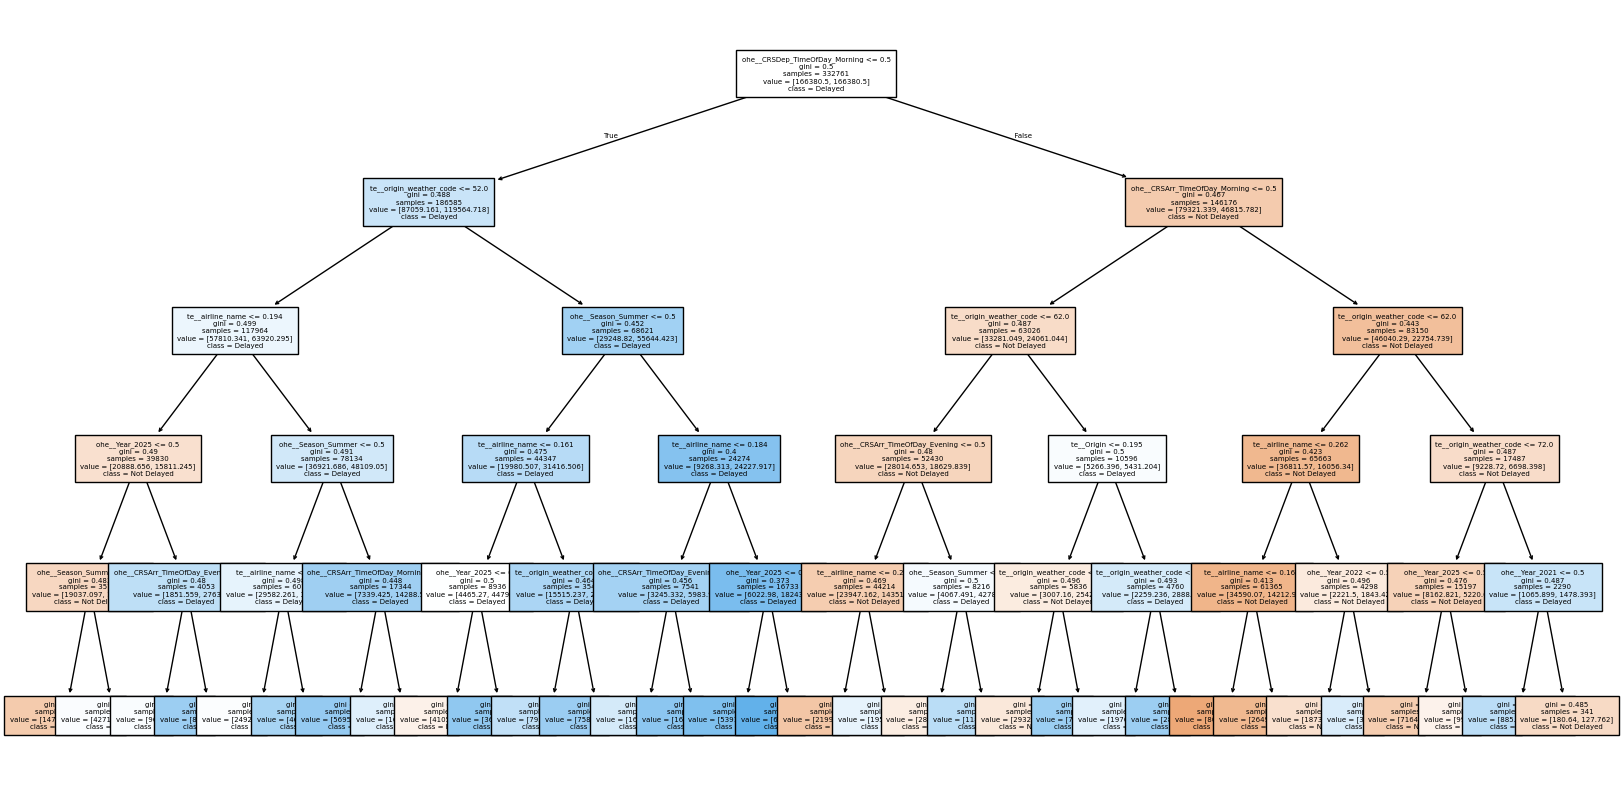

In [69]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

dt_model = dt_pipeline.named_steps["dt"]

plt.figure(figsize = (20,10))
plot_tree(dt_model, feature_names = list(dt_preprocessor.get_feature_names_out()),
          filled = True, class_names = ["Not Delayed", "Delayed"], 
          fontsize = 5)
plt.show()

#### Random Forest Feature Importance

In [73]:
rf_model = rf_pipeline.named_steps["rf"]
rf_preproc = rf_pipeline.named_steps["preprocessor"]
feature_names = rf_preproc.get_feature_names_out()
importances = rf_model.feature_importances_

top_k = 10
headers = ["feature", "importance"]
rows = sorted(zip(feature_names, importances), key = lambda x: x[1])[:top_k]

print(tabulate.tabulate(rows, headers, tablefmt = "simple"))

feature                           importance
------------------------------  ------------
ohe__Season_Winter                0.00274712
ohe__Season_Spring                0.00308852
ohe__CRSDep_TimeOfDay_Night       0.00385923
remainder__IsWeekend              0.00418828
remainder__origin_snowfall_sum    0.0044721
ohe__Season_Summer                0.00487558
ohe__Year_2021                    0.00533696
ohe__Year_2023                    0.00542261
ohe__Year_2022                    0.00560899
ohe__Year_2025                    0.00566868


Some commonly mentioned features include season, time of day, and year. 

#### XG Boost Feature Importance

In [99]:
# Get rankings
xg_model = xg_pipeline.named_steps["xgb"]
xg_preproc = xg_pipeline.named_steps["preprocessor"]
feature_names = xg_preproc.get_feature_names_out()
importances = xg_model.feature_importances_

top_k = 10
headers = ["feature", "importance"]
rows = sorted(zip(feature_names, importances), key = lambda x: x[1])[:top_k]

print(tabulate.tabulate(rows, headers, tablefmt = "simple"))

feature                                   importance
--------------------------------------  ------------
remainder__CosDay                         0
ohe__CRSDep_TimeOfDay_Night               0.00541257
remainder__origin_temperature_2m_range    0.00574432
remainder__origin_wind_speed_10m_max      0.00626226
remainder__origin_wind_gusts_10m_max      0.00715293
remainder__IsWeekend                      0.00758264
ohe__Season_Winter                        0.00836015
remainder__dest_precipitation_hours       0.00854842
remainder__dest_snowfall_sum              0.0085767
remainder__dest_wind_gusts_10m_max        0.00882445


##  XG Boost Hyperparameter Tuning

Based on our comparisons, XG Boost had the highest test average precision. So, we will do a random CV search to discover better hyperparameters and then conduct a stratified CV run to find an optimal probability threshold.

In [74]:
from sklearn.model_selection import RandomizedSearchCV

# Set up preprocessing
preprocessor = ColumnTransformer(
    transformers = [
        ("ohe", OneHotEncoder(drop = "first"), oh_encoding_cols),
        ("te", TargetEncoder(smoothing = 10), target_encoding_cols)
    ], remainder = "passthrough"
)

# Build pipeline
xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("xgb", XGBClassifier(
        eval_metric = "logloss",
        scale_pos_weight = (y_train == 0).sum()/(y_train == 1).sum(),
        random_state = SEED
    ))
])

# Parameter space
scoring = "average_precision"
param_space = {
    "xgb__n_estimators": [100, 200, 300, 500],
    "xgb__max_depth": [3, 4, 5, 6],
    "xgb__learning_rate": [0.03, 0.05, 0.1],
    "xgb__min_child_weight": [1, 3, 5],
    "xgb__subsample": [0.7, 0.85, 1.0],
    "xgb__colsample_bytree": [0.7, 0.85, 1.0]
    
    }

# Initalize search
xgb_search = RandomizedSearchCV(
    xgb_pipeline,
    param_distributions = param_space,
    n_iter = 10,
    scoring = scoring,
    cv = 5,
    n_jobs = -1,
    verbose = 2,
    random_state = SEED
)

In [75]:
# Fit to X_train and y_train
xgb_search.fit(X_train, y_train) # Display results

Fitting 5 folds for each of 10 candidates, totalling 50 fits


/opt/homebrew/Cellar/python@3.13/3.13.0_1/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/opt/homebrew/Cellar/python@3.13/3.13.0_1/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/opt/homebrew/Cellar/python@3.13/3.13.0_1/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. Se

[CV] END xgb__colsample_bytree=0.85, xgb__learning_rate=0.1, xgb__max_depth=5, xgb__min_child_weight=1, xgb__n_estimators=100, xgb__subsample=0.7; total time=   9.2s
[CV] END xgb__colsample_bytree=0.85, xgb__learning_rate=0.1, xgb__max_depth=5, xgb__min_child_weight=1, xgb__n_estimators=100, xgb__subsample=0.7; total time=   9.1s
[CV] END xgb__colsample_bytree=0.85, xgb__learning_rate=0.1, xgb__max_depth=5, xgb__min_child_weight=1, xgb__n_estimators=100, xgb__subsample=0.7; total time=   9.3s
[CV] END xgb__colsample_bytree=0.85, xgb__learning_rate=0.1, xgb__max_depth=5, xgb__min_child_weight=1, xgb__n_estimators=100, xgb__subsample=0.7; total time=   9.6s
[CV] END xgb__colsample_bytree=0.85, xgb__learning_rate=0.1, xgb__max_depth=5, xgb__min_child_weight=1, xgb__n_estimators=100, xgb__subsample=0.7; total time=   9.4s
[CV] END xgb__colsample_bytree=0.7, xgb__learning_rate=0.1, xgb__max_depth=4, xgb__min_child_weight=5, xgb__n_estimators=100, xgb__subsample=1.0; total time=   7.9s
[CV] 

,estimator,"Pipeline(step...=None, ...))])"
,param_distributions,"{'xgb__colsample_bytree': [0.7, 0.85, ...], 'xgb__learning_rate': [0.03, 0.05, ...], 'xgb__max_depth': [3, 4, ...], 'xgb__min_child_weight': [1, 3, ...], ...}"
,n_iter,10
,scoring,'average_precision'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,100
,error_score,nan


In [76]:
print(f"Best {scoring} (CV): {xgb_search.best_score_}")
print(f"Best hyperparameters: {xgb_search.best_params_}")

Best average_precision (CV): 0.47264788286134196
Best hyperparameters: {'xgb__subsample': 0.85, 'xgb__n_estimators': 500, 'xgb__min_child_weight': 1, 'xgb__max_depth': 5, 'xgb__learning_rate': 0.1, 'xgb__colsample_bytree': 0.85}


In [81]:
# Compare with best default average precision
test_metric_best_xgb = evaluate_model(xgb_search.best_estimator_, X_train, y_train, X_test, y_test)
comparison_df.loc["XGBoost"]["test_avg_precision"]

print(f"XGB with tuned hyperparameters: {test_metric_best_xgb["test_avg_precision"]}\nDefault XGB: {comparison_df.loc["XGBoost"]["test_avg_precision"]}")

XGB with tuned hyperparameters: 0.48435752049809966
Default XGB: 0.4782698405684459


#### Threshold tuning
Now run a quick test to find the ideal threshold at which to classify a flight as delayed.

In [96]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import average_precision_score, precision_score, recall_score, f1_score
import numpy as np

best_xgb_pipeline = xgb_search.best_estimator_
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

oof_probs = cross_val_predict(
    best_xgb_pipeline,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

thresholds = np.arange(0.05, 1.00, 0.05)

rows = []
for t in thresholds:
    y_pred = (oof_probs >= t).astype(int)
    rows.append({
        "threshold": t,
        "precision": precision_score(y_train, y_pred, zero_division=0),
        "recall": recall_score(y_train, y_pred, zero_division=0),
        "f1": f1_score(y_train, y_pred, zero_division=0),
        "n_alerts": y_pred.sum()
    })

threshold_df = pd.DataFrame(rows)

/opt/homebrew/Cellar/python@3.13/3.13.0_1/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/opt/homebrew/Cellar/python@3.13/3.13.0_1/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/opt/homebrew/Cellar/python@3.13/3.13.0_1/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. Se

In [97]:
threshold_df.sort_values("f1", ascending = False)

,threshold,precision,recall,f1,n_alerts
10,0.55,0.399370,0.573773,0.470943,91677
11,0.60,0.441662,0.495212,0.466907,71548
9,0.50,0.362388,0.648274,0.464897,114151
8,0.45,0.329387,0.718042,0.451608,139104
12,0.65,0.488356,0.412092,0.446994,53846
7,0.40,0.299777,0.782780,0.433528,166624
6,0.35,0.272544,0.844165,0.412054,197645
13,0.70,0.541726,0.328078,0.408663,38645
5,0.30,0.247388,0.896789,0.387798,231317
4,0.25,0.225842,0.940637,0.364234,265774


It looks like we are best able to rank delayed flights when we have a somewhat stringent threshold of 0.55. Indeed it makes some sense because with such a threshold we are really only picking flights that we are quite confident will be delayed.

## Precision @ k

Lastly, we examine our best XGB classifier's efficacy of ranking delayed flights. As discussed in the README, the goal for this model is to be a decision support tool that can help direct the focus of the operations team at PHL. As such, we want to see how often the topmost ranked predictions are actually delayed flights (predictions with highest probability of y == 1). 

In [94]:
from flight_delay_prediction.utils.metrics import precision_at_k

for k in [10, 20, 50, 100, 250, 500, 1000, 10000, 100000]:
    p_at_k = precision_at_k(best_xgb_pipeline, X_test, y_test, k)
    print(f"Precision @ {k}: {p_at_k['actual'].mean():.3f}")

Precision @ 10: 1.000
Precision @ 20: 1.000
Precision @ 50: 1.000
Precision @ 100: 1.000
Precision @ 250: 0.988
Precision @ 500: 0.964
Precision @ 1000: 0.923
Precision @ 10000: 0.636
Precision @ 100000: 0.247


Our model does quite impressively, only seeing a drop off in precision @ k around 1000. In an operational context, it's unlikely that a team would be looking at the 1000 most likely delayed flights at a given time. Up until 500 flights, there is a 95% chance that the flight being predicted as delayed will actually arrive late.